In [1]:
## Check if positive counts are overdispersersed
import polars as pl 
import numpy as np 
data_path = '/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate'
input_data = 'train_df'
df = pl.scan_parquet(f'{data_path}/input/{input_data}.parquet')

In [ ]:
config_dict = {
    # Binning configs
    'fine_bin_mins' : 5,
    'coarse_bin_mins' : 60,

    # Train, burn in, test validation split config
    'train_days' : 7,
    'burn_in_days' : 7,
    'validation_days' : 7,
    'test_days' : 7,
    
    # Min Params
    'mean_min' : 1e-8,
    'var_min' : 1e-8,
    'min_mean_var_diff' : 1e-8,
    
    # Hyperparameter defaults these are overwritten by the values in hyperparameter dictionary
    # Smoothing target 0 is the vector 1 is the shape and 2 is the rate
    'w' : 0.1,
    'smooth_a' : 0.1, 
    'smooth_k' : 0.1, 
    'linear_smooth' : True, 
    'smoothing_target' : 0, 
    'hurdle_model' : True,
    
    # setting the seed (used in k means) and clustering method
    'seed' : 110,
    'clustering_method' : 'k_means',
    'clustering_matrix_name' : 'u',
    
    # Calibration outputs and degen threshold
    'degen_threshold' : 0.99, 
    'calibration_thresholds' : np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 0.9], dtype='float64'),

    # Tells us whether to evaluate only on the validation set
    'use_validation' : True,
    }

In [3]:
# Helper functions outputing dicitonaries
def get_bin_metrics(config_dict=config_dict):
    ''' 
    Returns a dictionary containing all information needed about bin length these numbers are needed throughout the pipeline
    '''
    # Check that bin length divides number of days
    assert 24 * 60 % config_dict['fine_bin_mins'] == 0
    assert 24 * 60 % config_dict['coarse_bin_mins'] == 0
    assert config_dict['coarse_bin_mins'] % config_dict['fine_bin_mins'] == 0

    output_dict = {'fine_bins_per_day' : 24 * 60 // config_dict['fine_bin_mins']}
    output_dict['fine_bins_per_week'] = output_dict['fine_bins_per_day'] * 7
    output_dict['fine_bins_per_coarse_bin'] = config_dict['coarse_bin_mins'] // config_dict['fine_bin_mins']
    output_dict['coarse_bins_per_week'] = output_dict['fine_bins_per_week'] // output_dict['fine_bins_per_coarse_bin']
    output_dict['fine_bin_seconds'] = config_dict['fine_bin_mins'] * 60 

    return output_dict
    
# Adding the fine_bins_per_coarse_bin to the train_test_split_dict
def add_training_denom(bin_metric_dict, config_dict=config_dict):
    ''' 
    Finds how many fine bins are used for the estimate of the iniatial parameter.
    This is the denominator on the mean estimate as it is counts/bins and is similarly used in the variance estimate.

    This fucntion assumes train days is a multiple of 7 to work

    Returns:
        An updated bin metric dict with a new column train denom
    '''
    assert config_dict['train_days'] % 7 == 0
    bin_metric_dict['train_denom'] = bin_metric_dict['fine_bins_per_coarse_bin'] * (config_dict['train_days'] // 7)
    return bin_metric_dict

bin_metric_dict = get_bin_metrics()
bin_metric_dict = add_training_denom(bin_metric_dict)

def create_counts_data(df):
    ''' 
    Gets the counts per fine bin x source user from the data
    '''
    df = df.with_columns(time = pl.col('time').dt.total_seconds())
    df = df.with_columns(fine_bin_id = pl.col('time') // bin_metric_dict['fine_bin_seconds'])
    df = df.group_by(['source_user@domain', 'fine_bin_id']).agg(pl.len().alias('count')).collect()
    df = df.with_columns(fine_bin_pos_in_week = pl.col('fine_bin_id') % bin_metric_dict['fine_bins_per_week'])
    df = df.with_columns(coarse_bin_id = pl.col('fine_bin_pos_in_week') // bin_metric_dict['fine_bins_per_coarse_bin'])
                                     
    return df

df = create_counts_data(df)

stats_df = df.group_by(['source_user@domain', 'coarse_bin_id']).agg(mu = pl.col('count').mean(), sigma2= pl.col('count').var())
stats_df = stats_df.with_columns(dispersion= pl.col('sigma2') / pl.col('mu'))

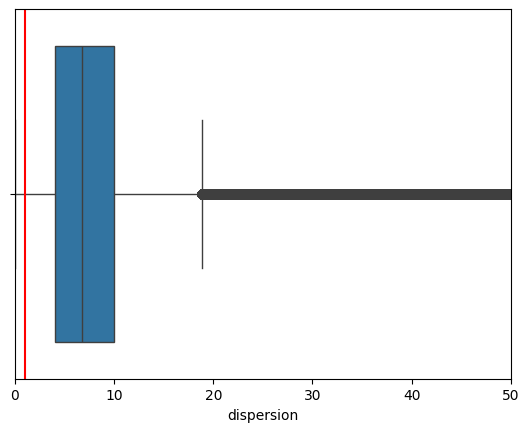

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=stats_df['dispersion'].drop_nulls())
plt.axvline(1, color='red')
plt.xlim((0,50))
plt.show()

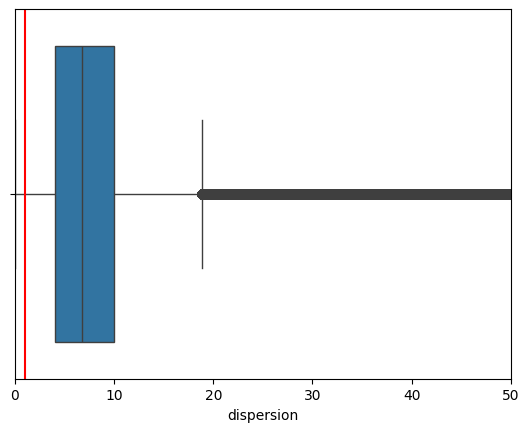